In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [14]:
df = pd.read_csv("../data/ethiopia.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [15]:
df["Country"] = "Ethiopia"
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

In [16]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3


In [33]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)

Duplicate rows found: 0


In [18]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [34]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [35]:
missing_df[missing_df["Missing %"] > 5]

,Missing Count,Missing %


In [36]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN",
        "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)

outliers = np.abs(z_scores) > 3

print("Outlier rows:", outliers.any(axis=1).sum())

Outlier rows: 168


I choose to CAP outliers instead of removing them because climate extremes are meaningful and part of real weather variability. This preserves time-series integrity

In [37]:
for col in cols:
    mean = df[col].mean()
    std = df[col].std()

    upper = mean + 3 * std
    lower = mean - 3 * std
    df[col] = np.where(df[col] > upper, upper, df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])

In [26]:


df[cols].head()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,11.73,22.75,3.44,0.0,41.79,2.73,5.07
1,12.30,24.01,4.09,0.0,33.29,2.39,4.19
2,12.49,24.17,3.97,0.0,33.83,1.77,2.76
3,14.08,23.78,6.90,0.0,38.84,0.87,1.28
4,14.06,23.15,7.32,0.0,47.07,1.34,2.14


In [38]:
df = df.sort_values("Date")
df = df.ffill()

In [39]:
df = df.dropna(thresh=int(0.7 * df.shape[1]))

In [32]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.068679,23.199175,10.230320,12.971631,3.440719,68.415242,1.979971,3.574889,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.374350,15.650000,2.405775,3.560000,0.000000,24.201074,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.820000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.040000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.360000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.530000,30.930000,15.680000,23.240000,22.500978,91.930000,4.047275,6.946407,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.897501,2.751471,2.598468,3.821239,5.374903,14.714652,0.689012,1.122582,0.099484,2.362462,NaN,3.477046


In [40]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

Monthly Average Temperature (Trend Over Time)

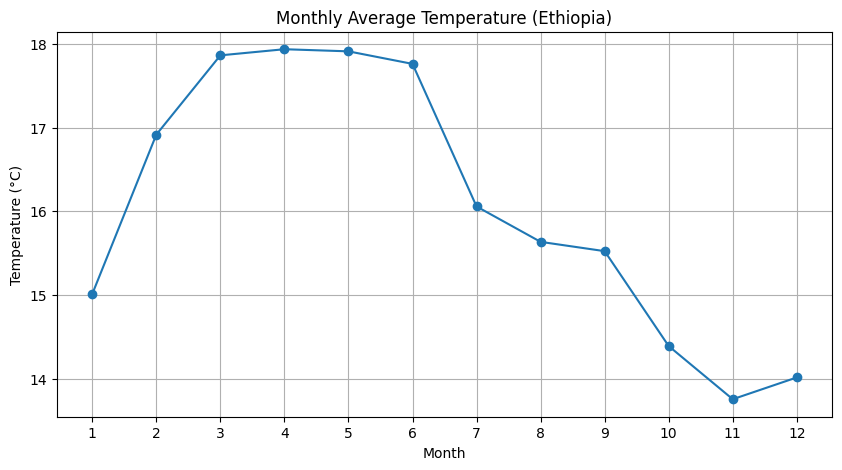

In [41]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature (Ethiopia)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

# Monthly Rainfall Pattern

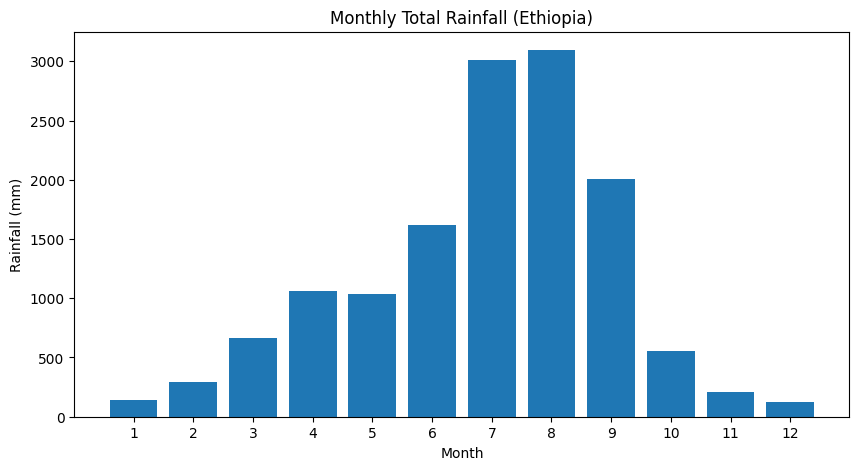

In [42]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure(figsize=(10,5))
plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Total Rainfall (Ethiopia)")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.xticks(range(1,13))
plt.show()

# Correlation Heatmap

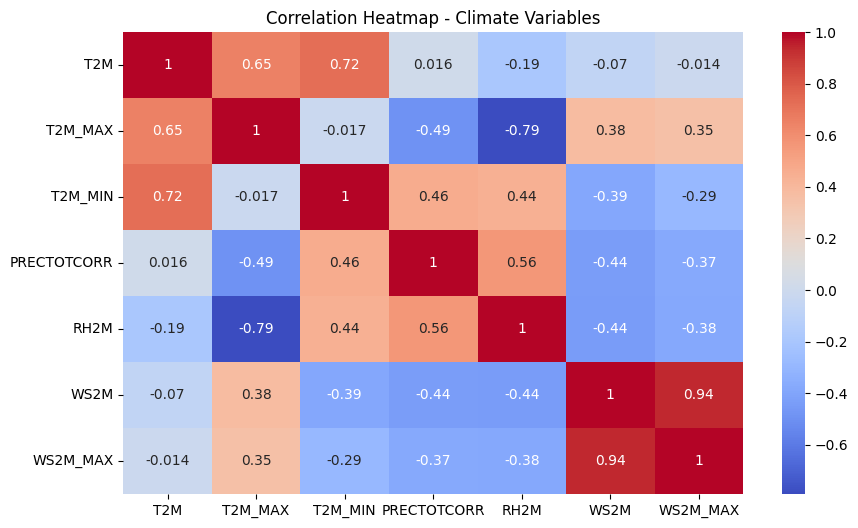

In [43]:
plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Climate Variables")
plt.show()

# Scatter Plot (Temperature vs Humidity)

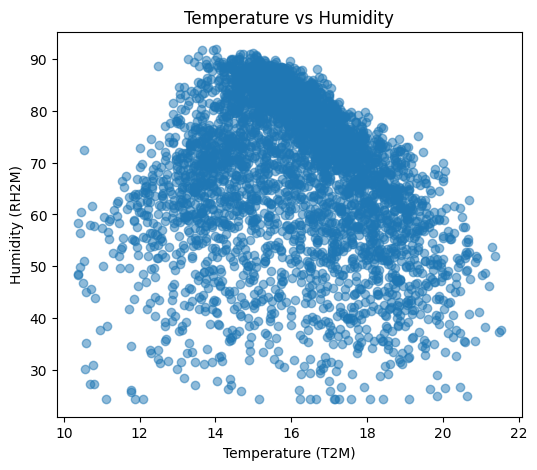

In [44]:
plt.figure(figsize=(6,5))
plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)
plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()

# Wind vs Temperature Range

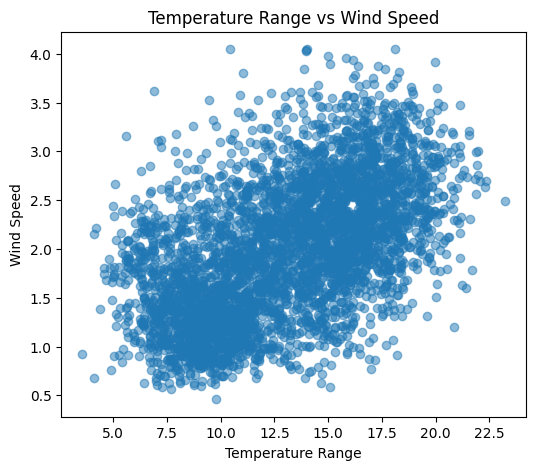

In [45]:
plt.figure(figsize=(6,5))
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)
plt.title("Temperature Range vs Wind Speed")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.show()

# Rainfall Distribution (Skew Check)

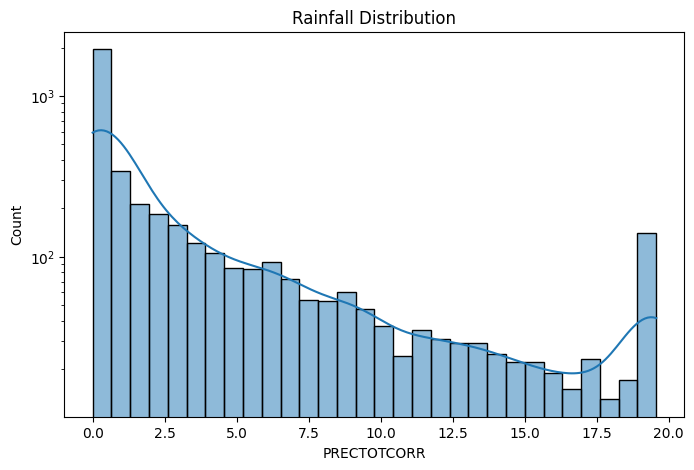

In [46]:
plt.figure(figsize=(8,5))
sns.histplot(df["PRECTOTCORR"], bins=30, kde=True)
plt.title("Rainfall Distribution")
plt.yscale("log")  # helps if skewed
plt.show()